<a href="https://colab.research.google.com/github/varshap2106/Hosting-a-Static-Webpage-on-GitHub-/blob/main/sales%20dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pandas numpy matplotlib seaborn

🚀 Generating Sales Dashboard...


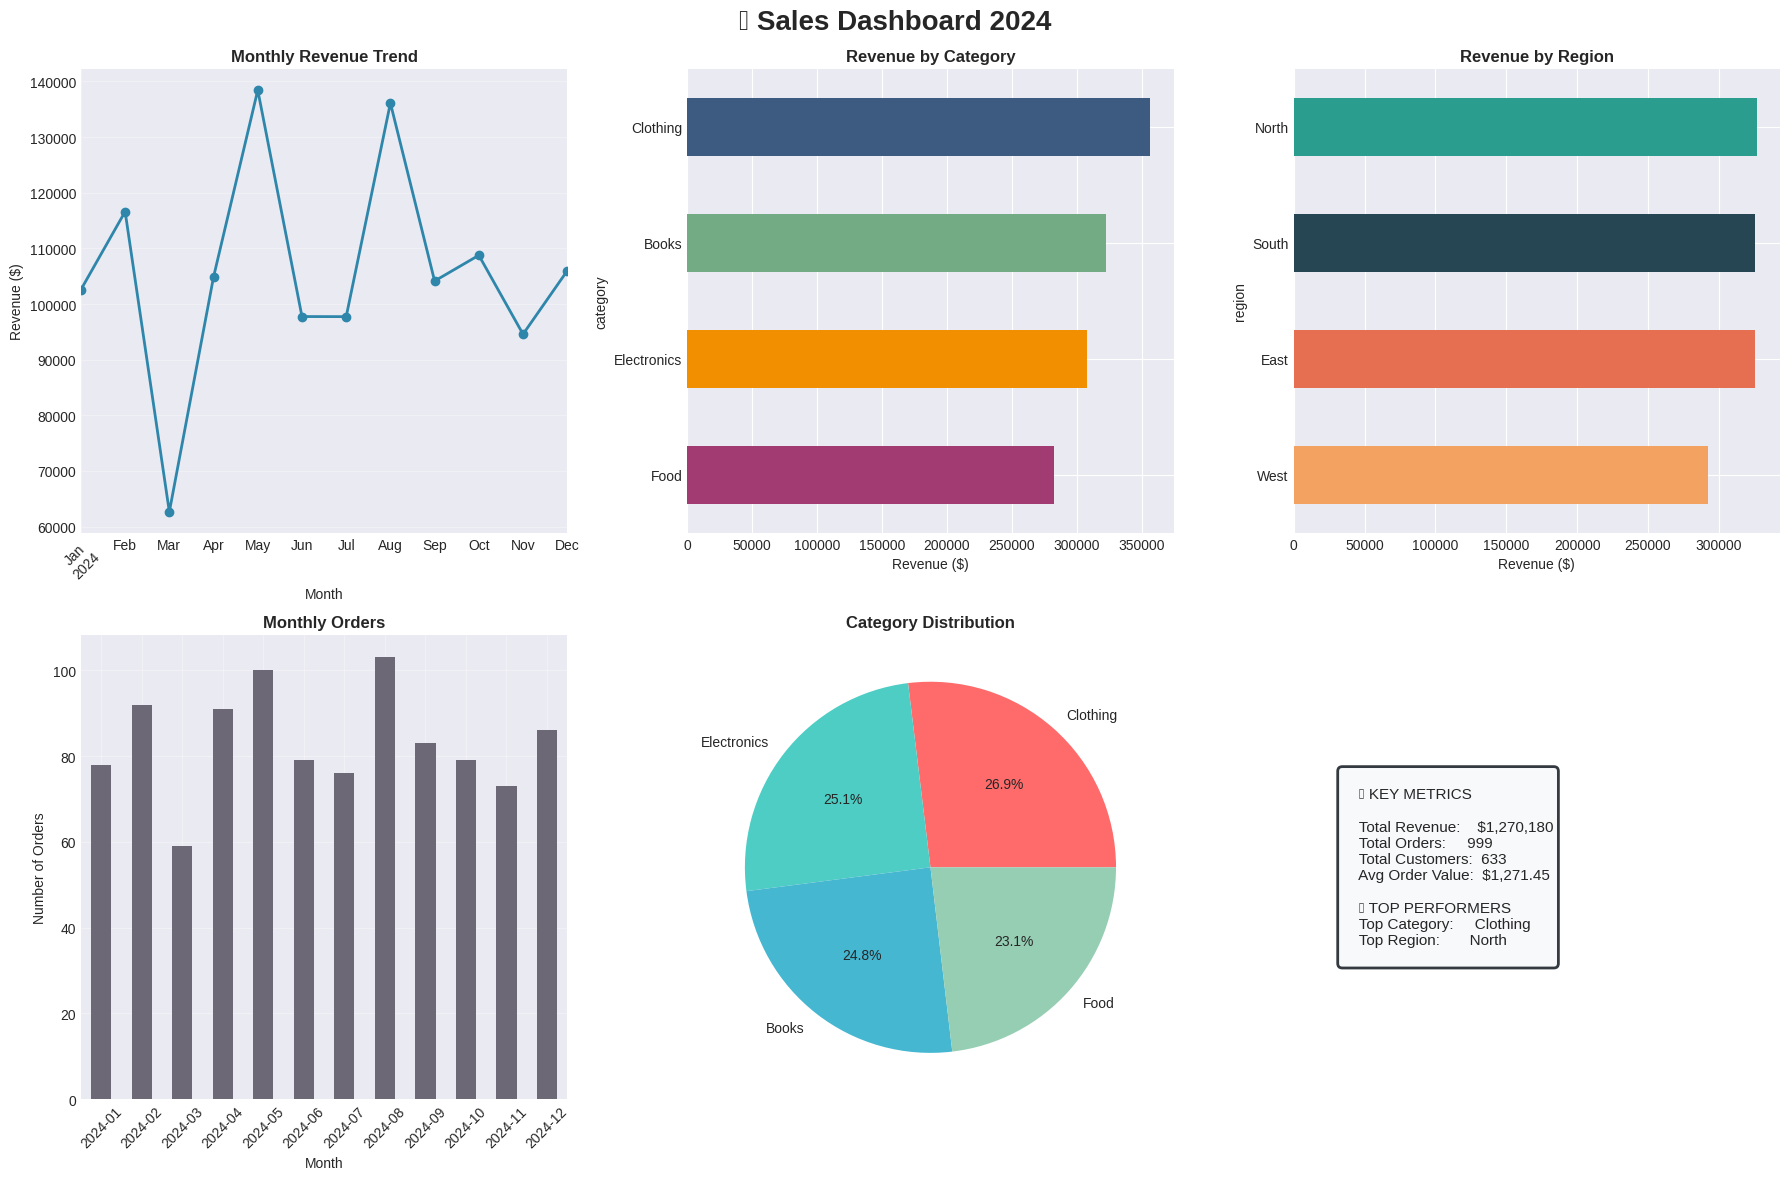

✅ Dashboard created successfully!


In [6]:
# Simplified version for Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate sample data
def generate_sample_data(n_records=1000):
    np.random.seed(42)
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2024, 12, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')

    data = {
        'order_date': np.random.choice(date_range, n_records),
        'region': np.random.choice(['North', 'South', 'East', 'West'], n_records),
        'category': np.random.choice(['Electronics', 'Clothing', 'Food', 'Books'], n_records),
        'quantity': np.random.randint(1, 10, n_records),
        'unit_price': np.random.randint(20, 500, n_records),
        'customer_id': np.random.randint(1000, 2000, n_records)
    }

    df = pd.DataFrame(data)
    df['sales'] = df['quantity'] * df['unit_price']
    df['revenue'] = df['sales']
    df = df.sort_values('order_date')
    return df

# Clean data
def clean_data(df):
    df['order_date'] = pd.to_datetime(df['order_date'])
    df = df.drop_duplicates()
    mean_sales = df['sales'].mean()
    std_sales = df['sales'].std()
    df = df[(df['sales'] >= mean_sales - 3*std_sales) &
            (df['sales'] <= mean_sales + 3*std_sales)]
    return df

# Calculate metrics
def calculate_metrics(df):
    metrics = {
        'Total Revenue': f"${df['revenue'].sum():,.0f}",
        'Total Orders': f"{len(df):,}",
        'Total Customers': f"{df['customer_id'].nunique():,}",
        'Average Order Value': f"${(df['revenue'].sum() / len(df)):,.2f}",
        'Top Category': df.groupby('category')['revenue'].sum().idxmax(),
        'Top Region': df.groupby('region')['revenue'].sum().idxmax()
    }
    return metrics

# Create dashboard
def create_dashboard(df, metrics):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('📊 Sales Dashboard 2024', fontsize=20, fontweight='bold')

    # 1. Monthly Revenue Trend
    ax1 = plt.subplot(2, 3, 1)
    monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()
    monthly_revenue.plot(kind='line', ax=ax1, color='#2E86AB', marker='o', linewidth=2)
    ax1.set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Revenue ($)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # 2. Revenue by Category
    ax2 = plt.subplot(2, 3, 2)
    category_revenue = df.groupby('category')['revenue'].sum().sort_values()
    category_revenue.plot(kind='barh', ax=ax2, color=['#A23B72', '#F18F01', '#73AB84', '#3D5A80'])
    ax2.set_title('Revenue by Category', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Revenue ($)')

    # 3. Revenue by Region
    ax3 = plt.subplot(2, 3, 3)
    region_revenue = df.groupby('region')['revenue'].sum().sort_values()
    region_revenue.plot(kind='barh', ax=ax3, color=['#F4A261', '#E76F51', '#264653', '#2A9D8F'])
    ax3.set_title('Revenue by Region', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Revenue ($)')

    # 4. Monthly Orders
    ax4 = plt.subplot(2, 3, 4)
    monthly_orders = df.groupby(df['order_date'].dt.to_period('M')).size()
    monthly_orders.plot(kind='bar', ax=ax4, color='#6D6875')
    ax4.set_title('Monthly Orders', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Month')
    ax4.set_ylabel('Number of Orders')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)

    # 5. Category Distribution
    ax5 = plt.subplot(2, 3, 5)
    category_dist = df['category'].value_counts()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    ax5.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', colors=colors)
    ax5.set_title('Category Distribution', fontsize=12, fontweight='bold')

    # 6. Key Metrics
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    metrics_text = f"""
    📈 KEY METRICS

    Total Revenue:    {metrics['Total Revenue']}
    Total Orders:     {metrics['Total Orders']}
    Total Customers:  {metrics['Total Customers']}
    Avg Order Value:  {metrics['Average Order Value']}

    🏆 TOP PERFORMERS
    Top Category:     {metrics['Top Category']}
    Top Region:       {metrics['Top Region']}
    """
    ax6.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#F8F9FA', edgecolor='#343A40', linewidth=2))

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    return fig

# Run everything
print("🚀 Generating Sales Dashboard...")
df = generate_sample_data(1000)
df = clean_data(df)
metrics = calculate_metrics(df)
fig = create_dashboard(df, metrics)
plt.show()
print("✅ Dashboard created successfully!")